In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 1. «Байесовский» генератор по категориям

In [12]:
import random
from typing import Dict, List, Tuple

class StyleGenerator:
    def __init__(self,
                 styles: Dict[str, List[str]],
                 counts: Dict[str, List[int]]):
        """
        styles: словарь категорий → список возможных значений
        counts: словарь категорий → соответствующие частоты из выборки
        """
        self.styles = styles
        self.counts = counts
        self.probs = self._compute_mle_distributions()

    def _compute_mle_distributions(self) -> Dict[str, List[float]]:
        """Вычисляем P(v) = count(v) / sum(counts) для каждой категории."""
        probs = {}
        for cat, vals in self.styles.items():
            cnts = self.counts[cat]
            total = sum(cnts)
            probs[cat] = [c/total for c in cnts]
        return probs

    def generate(self) -> Tuple[Dict[str, str], float]:
        """
        Генерирует один случайный стиль:
        - выбирает для каждой категории значение по P(v)
        - возвращает (словарь «категория→значение», P_совместная)
        """
        chosen = {}
        joint_p = 1.0
        for cat, vals in self.styles.items():
            p_dist = self.probs[cat]
            idx = random.choices(range(len(vals)), weights=p_dist, k=1)[0]
            chosen[cat] = vals[idx]
            joint_p *= p_dist[idx]
        return chosen, joint_p




In [13]:
styles = {
    'прическа':[
        'нет волос',
        'длинные в пучок',
        'длинные волнистые',
        'длинные прямые',
        'короткая волнистые',
        'короткая прямые',
        'короткая курчавые'
    ],
    'цвет волос':[
        'черный',
        'блонд',
        'каштановый',
        'пастельный розовый',
        'рыжий',
        'серебристо серый',
    ],
    'аксесуар':[
        'нет очков',
        'круглые очки',
        'солнцезащитные очки',
    ],
    'одежда':[
        'худи',
        'комбинезон',
        'футболка с круглым вырезом',
        'футболка с V-вырезом',
    ],
    'цвет одежды':[
        'черный',
        'синий',
        'серый',
        'зеленый',
        'оранжевый',
        'розовый',
        'красный',
        'белый'
    ],
}

styles_count = {
    'прическа':[
        7,
        0,
        1,
        23,
        1,
        11,
        7
    ],
    'цвет волос':[
        7,
        6,
        2,
        3,
        8,
        24,
    ],
    'аксесуар':[
        11,
        22,
        17,
    ],
    'одежда':[
        7,
        18,
        19,
        6,
    ],
    'цвет одежды':[
        4,
        5,
        6,
        8,
        6,
        8,
        7,
        6
    ],
}

In [14]:
gen = StyleGenerator(styles, styles_count)
for i in range(5):
    style, prob = gen.generate()
    print(f"Пример {i+1}:")
    for cat, val in style.items():
        print(f"  {cat}: {val}")
    print(f"  P(стиль) = {prob:.5f}\n")

Пример 1:
  прическа: короткая прямые
  цвет волос: серебристо серый
  аксесуар: круглые очки
  одежда: комбинезон
  цвет одежды: серый
  P(стиль) = 0.00201

Пример 2:
  прическа: длинные прямые
  цвет волос: черный
  аксесуар: круглые очки
  одежда: футболка с круглым вырезом
  цвет одежды: серый
  P(стиль) = 0.00129

Пример 3:
  прическа: нет волос
  цвет волос: серебристо серый
  аксесуар: круглые очки
  одежда: футболка с круглым вырезом
  цвет одежды: черный
  P(стиль) = 0.00090

Пример 4:
  прическа: длинные прямые
  цвет волос: блонд
  аксесуар: нет очков
  одежда: комбинезон
  цвет одежды: розовый
  P(стиль) = 0.00070

Пример 5:
  прическа: длинные прямые
  цвет волос: серебристо серый
  аксесуар: нет очков
  одежда: комбинезон
  цвет одежды: красный
  P(стиль) = 0.00245



In [76]:
samples = [gen.generate()[0] for _ in range(50000)]
samples[0]

{'прическа': 'длинные прямые',
 'цвет волос': 'серебристо серый',
 'аксесуар': 'солнцезащитные очки',
 'одежда': 'футболка с круглым вырезом',
 'цвет одежды': 'белый'}

In [77]:
from collections import Counter
import pandas as pd


# 1. Считаем, сколько раз встретилось каждое значение
counters = {cat: Counter() for cat in styles}
for style in samples:
    for cat, val in style.items():
        counters[cat][val] += 1



In [78]:
# 2. Формируем таблицу сравнения
rows = []
total_samples = len(samples)
for cat, vals in styles.items():
    total_count = sum(styles_count[cat])
    for val, count in zip(vals, styles_count[cat]):
        theo_p = count / total_count
        emp_p  = counters[cat][val] / total_samples
        rows.append({
            "Категория":      cat,
            "Значение":       val,
            "Теоретическая P": theo_p,
            "Эмпирическая P": emp_p,
            "Отклонение":     emp_p - theo_p
        })

df = pd.DataFrame(rows)


In [80]:
print(df)

      Категория                    Значение  Теоретическая P  Эмпирическая P  \
0      прическа                   нет волос             0.14         0.13944   
1      прическа             длинные в пучок             0.00         0.00000   
2      прическа           длинные волнистые             0.02         0.01942   
3      прическа              длинные прямые             0.46         0.45978   
4      прическа          короткая волнистые             0.02         0.01910   
5      прическа             короткая прямые             0.22         0.22290   
6      прическа           короткая курчавые             0.14         0.13936   
7    цвет волос                      черный             0.14         0.14032   
8    цвет волос                       блонд             0.12         0.11900   
9    цвет волос                  каштановый             0.04         0.03938   
10   цвет волос          пастельный розовый             0.06         0.06218   
11   цвет волос                       ры

In [79]:
threshold = 0.005

# 1. Находим максимальное абсолютное отклонение
max_dev = df['Отклонение'].abs().max()
print(f"Максимальное отклонение: {max_dev:.4f}")

# 2. Отфильтруем все строки, где |Отклонение| > threshold
anomalies = df[df['Отклонение'].abs() > threshold]
print(f"Строк с отклонением более {threshold}: {len(anomalies)}")
print(anomalies.to_string(index=False))

df.to_csv("prob_comparison_full_50k.csv", index=False, encoding="utf-8-sig")
anomalies.to_csv("prob_comparison_anomalies_50k.csv", index=False, encoding="utf-8-sig")

Максимальное отклонение: 0.0036
Строк с отклонением более 0.005: 0
Empty DataFrame
Columns: [Категория, Значение, Теоретическая P, Эмпирическая P, Отклонение]
Index: []


1. на 10.000 появляются строки с отклонением более 0.005 (3-8 строк)
2. на 50.000 строк с отклонением нет

# 2. Пиксельный байес-генератор аватаров

In [81]:
import os
import re
import numpy as np
from PIL import Image

class PixelGenerator:
    def __init__(self, avatars_dir: str):
        pattern = re.compile(r"^avataaars \(\d+\)\.png$")
        files = [
            os.path.join(avatars_dir, f)
            for f in os.listdir(avatars_dir)
            if pattern.match(f)
        ]
        if not files:
            raise ValueError(f"No avatars found in {avatars_dir}")

        imgs = [np.array(Image.open(fp)) for fp in files]
        h, w, _ = imgs[0].shape

        # Счётчики для каналов R,G,B: shape = (h, w, 256)
        counts = [np.zeros((h, w, 256), dtype=np.uint32) for _ in range(3)]
        for img in imgs:
            for c in range(3):
                vals = img[..., c].flatten()
                # считаем вхождения каждого значения v в каждом пикселе отдельно
                for i in range(h):
                    for j in range(w):
                        v = img[i, j, c]
                        counts[c][i, j, v] += 1

        # Превращаем счётчики в вероятности
        self.P = []
        for cnt in counts:
            total = cnt.sum(axis=2, keepdims=True)
            total[total == 0] = 1
            self.P.append(cnt / total)

        self.h, self.w = h, w

    def generate(self):
        img = np.zeros((self.h, self.w, 3), dtype=np.uint8)
        logp = 0.0
        for c in range(3):
            for i in range(self.h):
                for j in range(self.w):
                    p_dist = self.P[c][i, j]
                    v = np.random.choice(256, p=p_dist)
                    img[i, j, c] = v
                    logp += np.log(p_dist[v] + 1e-12)
        joint_p = np.exp(logp)
        return Image.fromarray(img), joint_p



In [82]:
path = "/content/drive/MyDrive/itmo/2025_deep_gen_models"
gen = PixelGenerator(path + "/avatars/")
for idx in range(5):
    avatar, prob = gen.generate()
    avatar.save(f"generated_{idx+1:02d}.png")
    print(f"generated_{idx+1:02d}.png — P = {prob:.3e}")

generated_01.png — P = 0.000e+00
generated_02.png — P = 0.000e+00
generated_03.png — P = 0.000e+00
generated_04.png — P = 0.000e+00
generated_05.png — P = 0.000e+00


In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

original_dir = "/content/drive/MyDrive/itmo/2025_deep_gen_models/avatars"
generated_files = [f"/content/drive/MyDrive/itmo/2025_deep_gen_models/generateds/generated_{i:02d}.png" for i in range(1, 6)]

import re
pattern = re.compile(r"^avataaars \(\d+\)\.png$")

originals = []
for fname in os.listdir(original_dir):
    if pattern.match(fname):
        img = np.array(Image.open(os.path.join(original_dir, fname)))
        originals.append(img)
originals = np.stack(originals)  # shape (N_orig, H, W, 3)

generated = [np.array(Image.open(path)) for path in generated_files]
generated = np.stack(generated)  # shape (5, H, W, 3)




In [84]:
def plot_channel_hist(channel_idx, title):
    plt.figure()

    data_orig = originals[..., channel_idx].ravel()
    plt.hist(data_orig, bins=256, density=True, alpha=0.5, label="Оригинал")

    data_gen = generated[..., channel_idx].ravel()
    plt.hist(data_gen, bins=256, density=True, alpha=0.5, label="Сгенерировано")
    plt.title(title)
    plt.xlabel("Значение канала (0-255)")
    plt.ylabel("Плотность вероятности")
    plt.legend()
    plt.show()

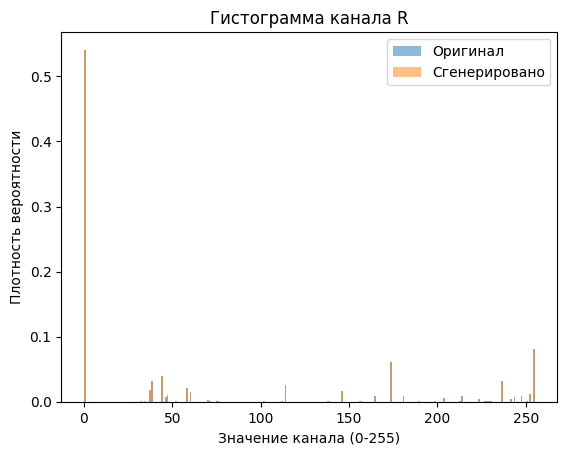

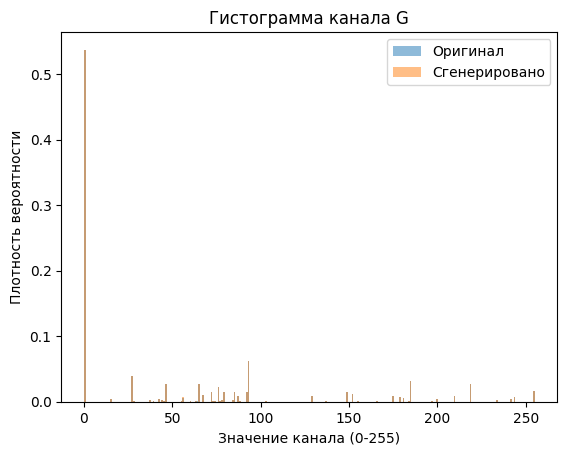

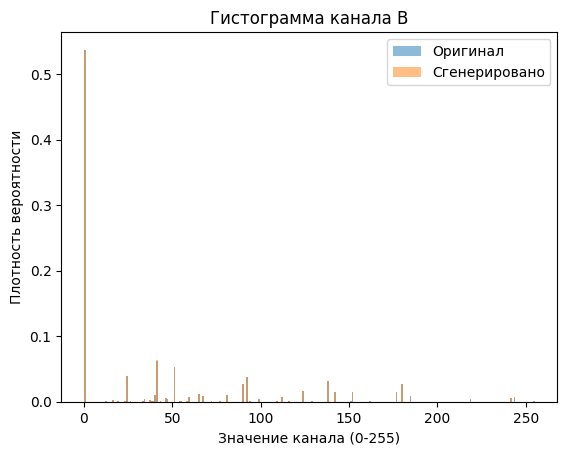

In [85]:
# Построить гистограммы для R, G, B
plot_channel_hist(0, "Гистограмма канала R")
plot_channel_hist(1, "Гистограмма канала G")
plot_channel_hist(2, "Гистограмма канала B")

Генератор успешно восстанавливает распределения по каналам R, G, B — гистограммы сгенерированных изображений совпадают с оригинальными.

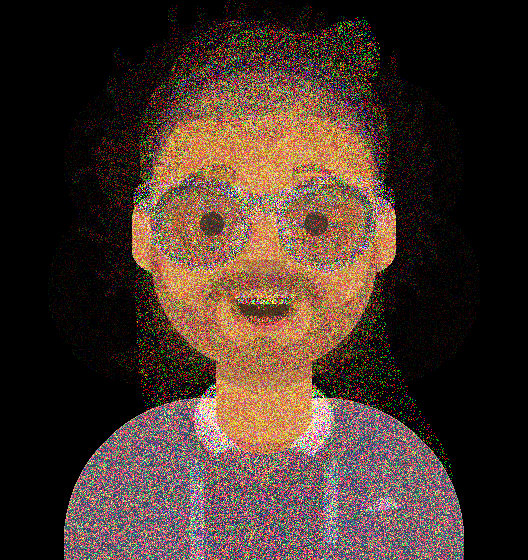

In [88]:
from IPython.display import Image as IPImage

IPImage('/content/generated_01.png')

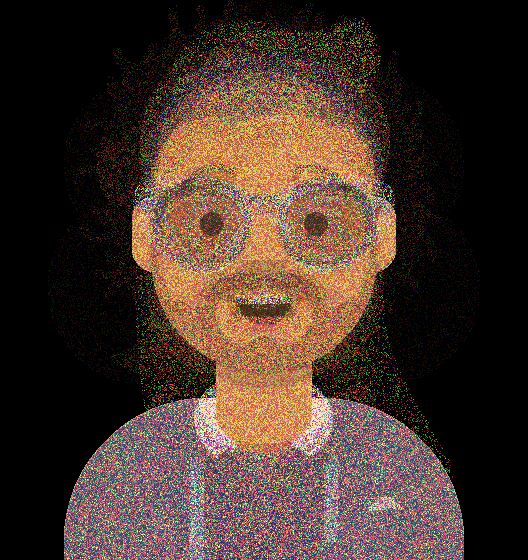

In [89]:
IPImage('/content/generated_02.png')

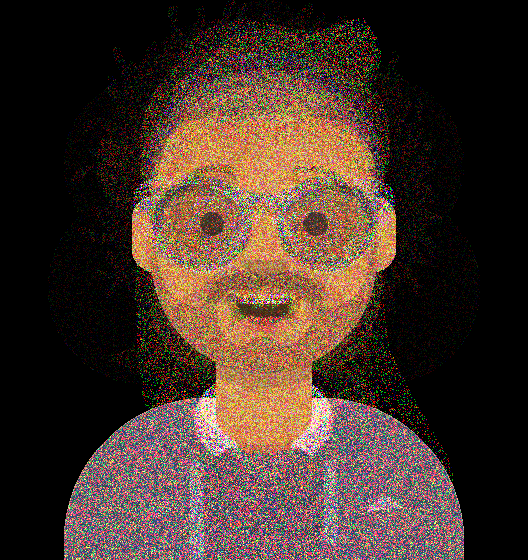

In [90]:
IPImage('/content/generated_03.png')

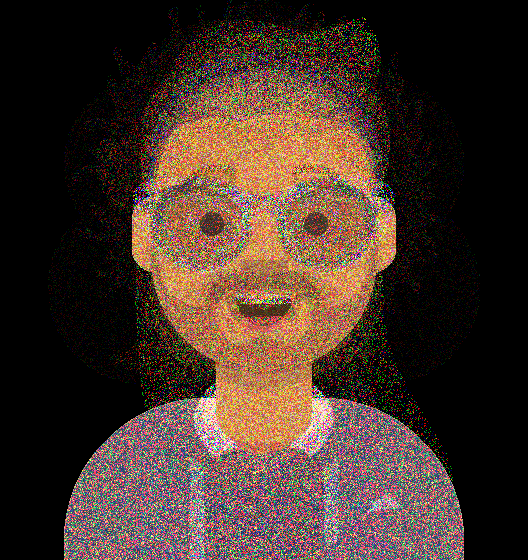

In [91]:
IPImage('/content/generated_04.png')

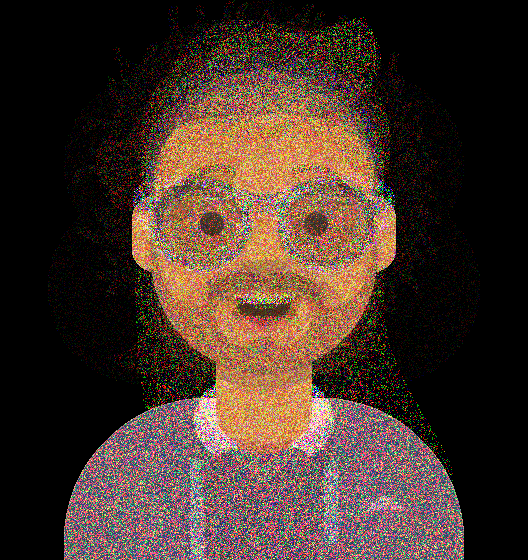

In [92]:
IPImage('/content/generated_05.png')